# 🏭 Clustering em Dados de Manufatura
## Tabular Playground Series – Jul 2022 (Kaggle)

Este notebook explora o desafio **Tabular Playground Series – Jul 2022**, que propõe um problema de 
**agrupamento (clustering) não supervisionado** em um conjunto de dados tabulares simulados de 
processos de manufatura.

O objetivo principal é identificar padrões e **segmentar as observações em clusters** que representem 
diferentes regimes de controle/condições de operação, utilizando algoritmos de Machine Learning 
não supervisionados (como K-Means).

Além de buscar uma boa qualidade de agrupamento, este projeto é estruturado pensando em 
**portfólio**, com foco em:

- Organização clara do fluxo de análise.
- Justificativa das decisões de pré-processamento e modelagem.
- Visualizações para interpretar os clusters encontrados.

---

## 🔍 Etapas do Projeto

1. Importação das bibliotecas e configuração do ambiente  
2. Carregamento e análise inicial do dataset (`data.csv`)  
3. Análise exploratória das features (distribuições, correlações)  
4. Pré-processamento (tratamento de nulos, escalonamento, seleção de features)  
5. Definição do número de clusters (métodos como elbow e/ou silhouette)  
6. Treinamento de modelos de clustering (K-Means e, opcionalmente, outro algoritmo)  
7. Interpretação dos clusters encontrados (tabelas e gráficos)  
8. Geração de rótulos para o `data.csv` e criação do arquivo de submissão (`submission.csv`)[web:56]

---

Portfolio Project • Autor: *Yukio Kitamura*  
Repositório: `https://github.com/KitamuraY3/portfolio-data-science-yukio`


# 1. BIBLIOTECAS:

In [39]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.utils import resample
from sklearn.decomposition import PCA

In [2]:
# VISUALIZAÇÃO:
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# 2. DATASET:

In [3]:
# CARREGAMENTO DOS DADOS:
df = pd.read_csv("data.csv")

In [4]:
print("INFORMAÇÕES BÁSICAS DO DATASET:")
print(f"Shape: {df.shape}")
print(f"Colunas: {list(df.columns)}")
print("\nPRIMEIRAS 5 LINHAS:")
df.head()

INFORMAÇÕES BÁSICAS DO DATASET:
Shape: (98000, 30)
Colunas: ['id', 'f_00', 'f_01', 'f_02', 'f_03', 'f_04', 'f_05', 'f_06', 'f_07', 'f_08', 'f_09', 'f_10', 'f_11', 'f_12', 'f_13', 'f_14', 'f_15', 'f_16', 'f_17', 'f_18', 'f_19', 'f_20', 'f_21', 'f_22', 'f_23', 'f_24', 'f_25', 'f_26', 'f_27', 'f_28']

PRIMEIRAS 5 LINHAS:


,id,f_00,f_01,f_02,f_03,f_04,f_05,f_06,f_07,f_08,f_09,f_10,f_11,f_12,f_13,f_14,f_15,f_16,f_17,f_18,f_19,f_20,f_21,f_22,f_23,f_24,f_25,f_26,f_27,f_28
0,0,-0.3894,-0.9128,0.6490,0.5890,-0.8308,0.7336,2.2586,2,13,14,5,13,6,6,-0.4698,0.3581,1.0681,-0.5597,-0.3669,-0.4784,-0.7570,-0.7636,-1.0904,1.1426,-0.8843,1.1379,1.3091,1.4630,0.8135
1,1,-0.6892,-0.4540,0.6542,0.9952,-1.6530,0.8638,-0.0907,2,3,6,4,6,16,9,0.5910,-0.3969,0.1458,-0.0308,0.4712,-0.4288,-0.0899,-1.7842,-0.8395,0.4597,1.7594,-0.2754,-0.8522,0.5625,-2.6805
2,2,0.8091,0.3246,-1.1706,-0.6245,0.1054,0.7839,1.9883,5,11,5,8,9,3,11,-0.6799,0.4693,0.3498,-0.2880,0.2915,-0.4135,-1.6024,1.1910,3.2671,-0.0883,-2.1686,-0.9750,1.3358,-1.1107,-3.6307
3,3,-0.5009,0.2290,0.2641,0.2315,0.4150,-1.2213,0.1388,6,2,13,8,9,6,4,-0.3895,0.6268,-1.0745,-1.5218,-1.1508,0.6193,1.2878,0.5328,1.0366,-2.0418,1.4405,-1.9002,-0.6308,-0.0506,0.2383
4,4,-0.6713,-1.0395,-0.2702,-1.8303,-0.2901,-1.8528,0.7819,8,7,5,3,1,13,11,-0.1207,-0.6156,-1.0644,0.4441,0.4283,-1.6288,-0.4349,0.3225,0.2843,-2.4384,1.4739,-1.0447,1.6027,-0.4053,-1.9873


In [ ]:
print(f"\n Tipos de dados:")
print(df.dtypes)

print(f"\n Informações gerais:")
print(df.info())

print(f"\n Estatísticas descritivas:")
print(df.describe())

print(f"\n Valores nulos por coluna:")
print(df.isnull().sum())

# 3. ANÁLISE EXPLORATÓRIA DOS DADOS (EDA):

In [ ]:
print("ANÁLISE INICIAL:")

print(f"\n Tipos de dados:")
print(df.dtypes)

print(f"\n Informações gerais:")
print(df.info())

print(f"\n Valores nulos por coluna:")
print(df.isnull().sum())

print(f"\n Estatísticas descritivas:")
print(df.describe())

In [ ]:
# VISUALIZAÇÕES - DISTRIBUIÇÕES:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

n_features = len(numeric_cols)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig_all, axes_all = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5))
axes_all = axes_all.ravel()

for i, col in enumerate(numeric_cols):
    ax = axes_all[i]
    sns.histplot(df[col].dropna(), bins=50, kde=True, stat='density', ax=ax, color='C0', edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Densidade')

for j in range(n_features, axes_all.size):
    axes_all[j].axis('off')

plt.suptitle('Distribuições de Todas as Features Numéricas', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

🔗 ANÁLISE DE CORRELAÇÃO
🏆 Top 10 features por variância:
id     800,341,500.0000
f_09            34.8681
f_10            22.0921
f_12            19.6542
f_11            17.6157
f_08            17.2420
f_13            16.9750
f_07            13.6297
f_25             2.4840
f_24             2.3809
dtype: float64


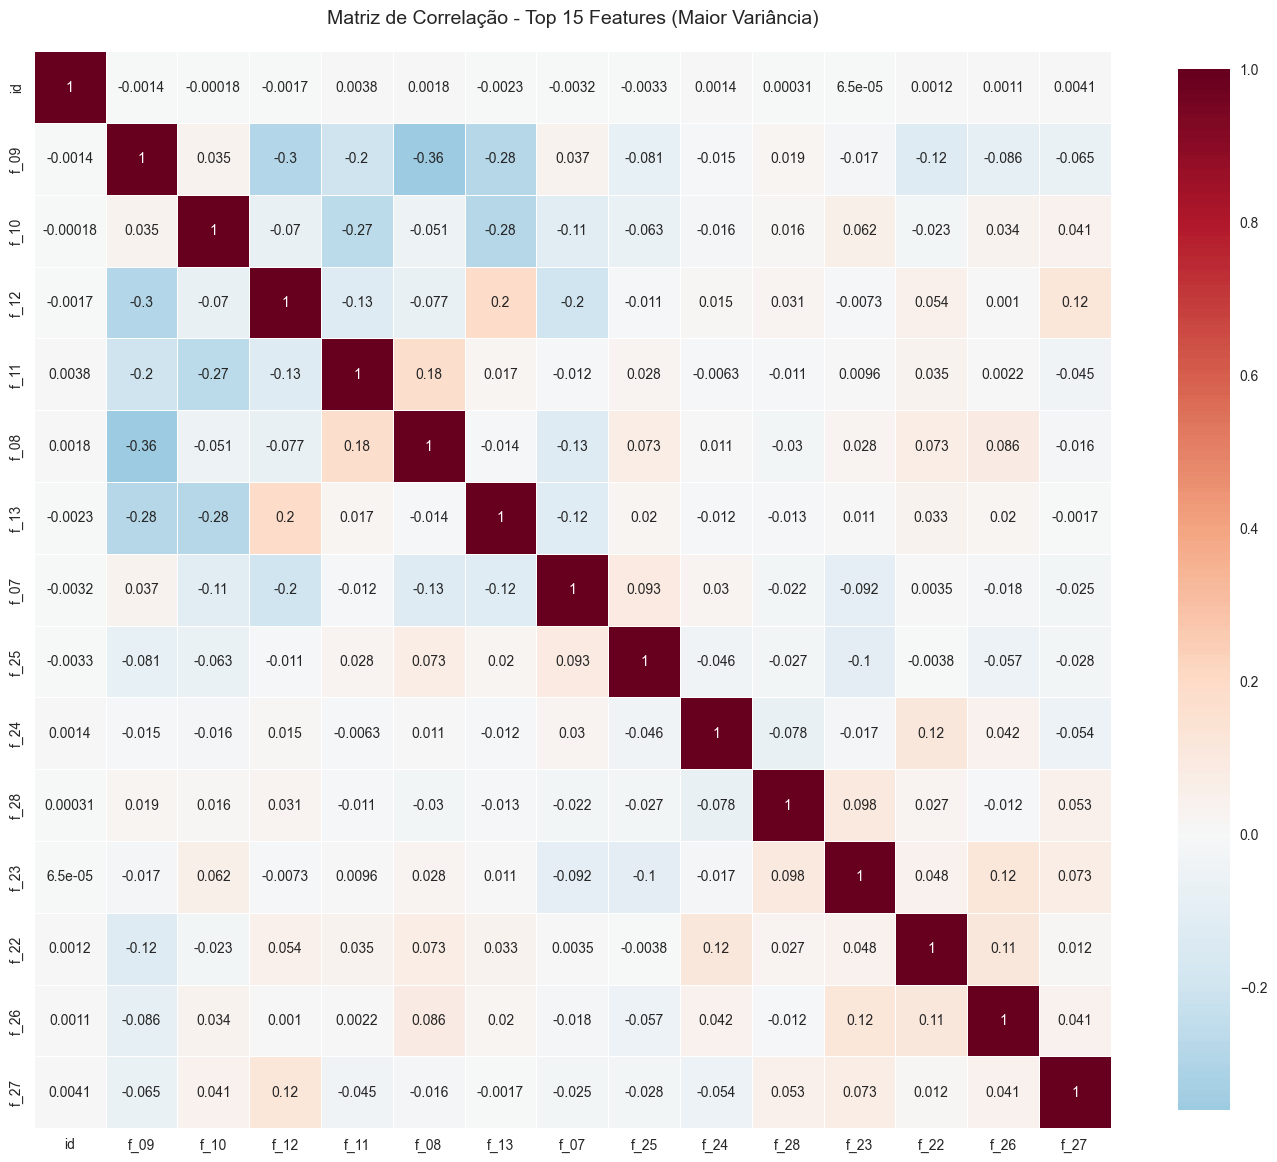

In [ ]:
# CORRELAÇÕES - Top 15 features com maior variância
print("ANÁLISE DE CORRELAÇÃO")

# Variância para priorizar features informativas
var_ranking = df[numeric_cols].var().sort_values(ascending=False)
print("Top 10 features por variância:")
print(var_ranking.head(10))

top_15_cols = var_ranking.head(15).index
corr_matrix = df[top_15_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.9})
plt.title('Matriz de Correlação - Top 15 Features (Maior Variância)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


# 4. PRÉ-PROCESSAMENTO:

In [17]:
# REMOÇÃO DA COLUNA ID:
df_features = df.drop(columns=["id"])
df_features.shape

(98000, 29)

In [21]:
# ESCALONAMENTO DOS DADOS:
num_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features[num_cols])
X_scaled.shape

(98000, 29)

# 5. DEFINIÇÃO DO NÚMERO DE CLUSTERS:

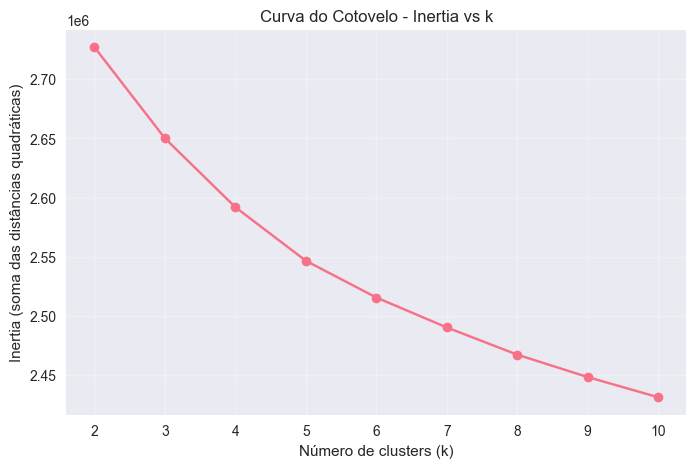

In [23]:
inertias = []
k_range = range(2, 11)  # k de 2 a 10

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,           # Número de clusters
        random_state=42,        # Aleatoriedade para reprodutibilidade
        n_init=10,              # Número de inicializações. Número de vezes que o algoritmo K-Means será executado com diferentes sementes de centróide
        init = 'k-means++',     # Método de inicialização dos centróides. 'k-means++' significa que o algoritmo escolherá os centros de cluster iniciais de forma inteligente para acelerar a convergência
        tol = 1e-5              # Tolerância para declarar convergência, ou seja, se a mudança nos centróides for menor que esse valor, o algoritmo será interrompido.
    )
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o")
plt.title("Curva do Cotovelo - Inertia vs k")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inertia (soma das distâncias quadráticas)")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
sil_scores = []
k_range = range(2, 11)

# AMOSTRA ALEATÓRIA DE 10.000 REGISTROS
X_sample = resample(
    X_scaled,
    n_samples=10_000,
    random_state=42,
    replace=False
)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        tol=1e-5,
        init='k-means++'
    )
    labels = kmeans.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    sil_scores.append(score)
    print(f"k = {k}: silhouette_score (amostra) = {score:.4f}")

k = 2: silhouette_score (amostra) = 0.0407
k = 3: silhouette_score (amostra) = 0.0375
k = 4: silhouette_score (amostra) = 0.0374
k = 5: silhouette_score (amostra) = 0.0370
k = 6: silhouette_score (amostra) = 0.0349
k = 7: silhouette_score (amostra) = 0.0338
k = 8: silhouette_score (amostra) = 0.0335
k = 9: silhouette_score (amostra) = 0.0328
k = 10: silhouette_score (amostra) = 0.0317


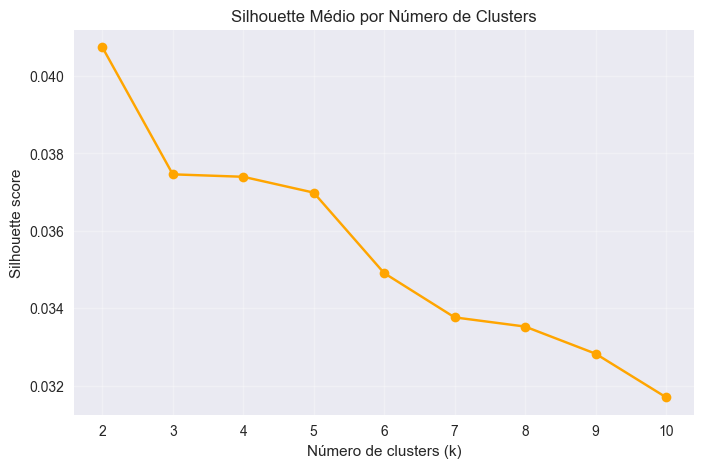

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, sil_scores, marker="o", color="orange")
plt.title("Silhouette Médio por Número de Clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette score")
plt.grid(True, alpha=0.3)
plt.show()

Com base na combinação da curva do cotovelo (inertia) e da análise do silhouette médio, 
optou-se por utilizar **k = 5 clusters** neste projeto. 

O valor k = 2 apresentou o maior silhouette, porém resulta em uma segmentação pouco informativa.
Já valores mais altos (k > 7) aumentam a complexidade sem ganho relevante de separação entre grupos.
Assim, k = 5 oferece um compromisso entre interpretabilidade dos clusters e qualidade do agrupamento.

# 6. TREINAMENTO DO MODELO - K-MEANS:

In [29]:
k_opt = 5  # NÚMERO DE CLUSTERS ESCOLHIDO DA ÚLTIMA ETAPA

kmeans_final = KMeans(
    n_clusters=k_opt,
    random_state=42,
    n_init=10,
    init='k-means++',
    tol=1e-5
)

In [30]:
# ATRIBUIÇÃO DOS RÓTULOS DE CLUSTER AO DATASET ORIGINAL
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [35]:
print(f"Inertia final: {kmeans_final.inertia_:.2f}")
print(f"Primeiros rótulos de cluster: {cluster_labels}")

Inertia final: 2546533.66
Primeiros rótulos de cluster: [2 1 2 ... 3 4 2]


# 7. INTERPRETAÇÃO DOS CLUSTERS ENCONTRADOS:

In [40]:
# PCA - 2 DIMENSÕES:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [41]:
# APLICAÇÃO DO PCA AOS CENTRÓIDES (kmeans_final.cluster_centers_):
centroids_2d = pca.transform(kmeans_final.cluster_centers_)

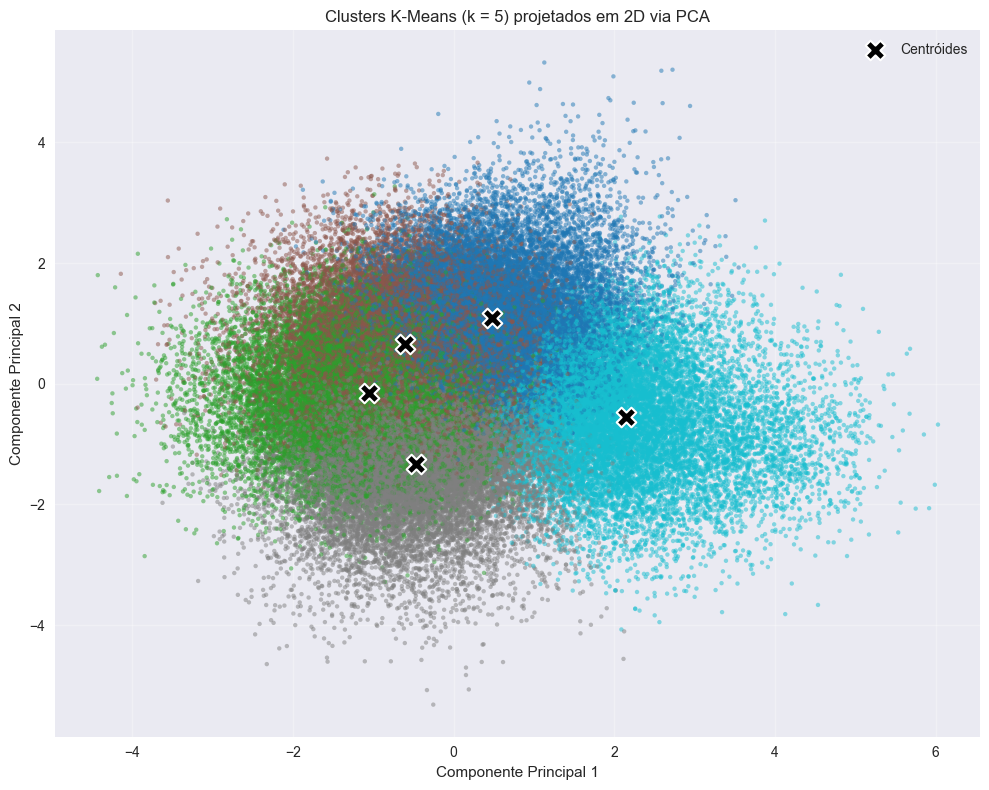

In [42]:
# VISUALIZAÇÃO DOS CLUSTERS EM 2D:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    cmap="tab10",
    alpha=0.5,
    s=10,
    edgecolor="none"
)

# DESTACANDO OS CENTRÓIDES COM UM 'X':
plt.scatter(
    centroids_2d[:, 0],
    centroids_2d[:, 1],
    c="black",
    s=200,
    marker="X",
    edgecolor="white",
    linewidth=1.5,
    label="Centróides"
)

plt.title("Clusters K-Means (k = 5) projetados em 2D via PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

A projeção dos dados em 2D via PCA mostra que os 5 clusters formados pelo K-Means 
ocupam regiões parcialmente sobrepostas, sem fronteiras claramente definidas. 
Ainda assim, nota-se que alguns grupos tendem a se concentrar em faixas específicas 
das componentes principais, e os centróides projetados aparecem como pontos de 
maior densidade em cada região.

Esse comportamento é consistente com os valores baixos de silhouette observados 
(≈ 0,03–0,04), indicando que os clusters capturam padrões sutis na distribuição 
multivariada dos dados, mas não representam grupos perfeitamente separados.

## 7.1. ANÁLISE NÚMERICA DOS CLUSTERS:

In [45]:
# CRIARÇÃO DO DATAFRAME FINAL COM RÓTULOS DE CLUSTER:
df_clusters = df.copy()
df_clusters["cluster"] = cluster_labels
df_clusters.head()

,id,f_00,f_01,f_02,f_03,f_04,f_05,f_06,f_07,f_08,f_09,f_10,f_11,f_12,f_13,f_14,f_15,f_16,f_17,f_18,f_19,f_20,f_21,f_22,f_23,f_24,f_25,f_26,f_27,f_28,cluster
0,0,-0.3894,-0.9128,0.6490,0.5890,-0.8308,0.7336,2.2586,2,13,14,5,13,6,6,-0.4698,0.3581,1.0681,-0.5597,-0.3669,-0.4784,-0.7570,-0.7636,-1.0904,1.1426,-0.8843,1.1379,1.3091,1.4630,0.8135,2
1,1,-0.6892,-0.4540,0.6542,0.9952,-1.6530,0.8638,-0.0907,2,3,6,4,6,16,9,0.5910,-0.3969,0.1458,-0.0308,0.4712,-0.4288,-0.0899,-1.7842,-0.8395,0.4597,1.7594,-0.2754,-0.8522,0.5625,-2.6805,1
2,2,0.8091,0.3246,-1.1706,-0.6245,0.1054,0.7839,1.9883,5,11,5,8,9,3,11,-0.6799,0.4693,0.3498,-0.2880,0.2915,-0.4135,-1.6024,1.1910,3.2671,-0.0883,-2.1686,-0.9750,1.3358,-1.1107,-3.6307,2
3,3,-0.5009,0.2290,0.2641,0.2315,0.4150,-1.2213,0.1388,6,2,13,8,9,6,4,-0.3895,0.6268,-1.0745,-1.5218,-1.1508,0.6193,1.2878,0.5328,1.0366,-2.0418,1.4405,-1.9002,-0.6308,-0.0506,0.2383,4
4,4,-0.6713,-1.0395,-0.2702,-1.8303,-0.2901,-1.8528,0.7819,8,7,5,3,1,13,11,-0.1207,-0.6156,-1.0644,0.4441,0.4283,-1.6288,-0.4349,0.3225,0.2843,-2.4384,1.4739,-1.0447,1.6027,-0.4053,-1.9873,1


In [47]:
# CONTAGEM DE AMOSTRAS POR CLUSTER:
cluster_counts = df_clusters["cluster"].value_counts().sort_index()
cluster_counts


cluster
0    21579
1    20899
2    20881
3    19159
4    15482
Name: count, dtype: int64

Os cinco clusters formados pelo K-Means apresentam tamanhos relativamente equilibrados,
com quatro grupos em torno de 20 mil observações e um cluster menor (~15 mil linhas).
Essa distribuição é desejável, pois evita a situação em que um único cluster domina o 
dataset, o que poderia indicar falta de segmentação efetiva.

In [52]:
numeric_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()

# VARIANCIA DAS FEATURES:
var_ranking = df_features[numeric_cols].var().sort_values(ascending=False)

print("Top 10 features por variância:")
top_features = var_ranking.head(10).index.tolist()
print(top_features)

# MÉDIA DAS FEATURES COM MAIOR VARIÂNCIA POR CLUSTER:
cluster_means = df_clusters.groupby("cluster")[top_features].mean()
cluster_means


Top 10 features por variância:
['f_09', 'f_10', 'f_12', 'f_11', 'f_08', 'f_13', 'f_07', 'f_25', 'f_24', 'f_28']


,f_09,f_10,f_12,f_11,f_08,f_13,f_07,f_25,f_24,f_28
cluster,,,,,,,,,,
0,8.8718,6.0183,5.4409,8.6709,5.4752,5.1419,10.1467,0.5415,0.3497,-0.3791
1,6.4363,4.6581,9.7191,8.3469,5.8848,11.2104,3.9455,-0.1123,0.0439,-0.2000
2,6.2534,7.8375,4.4296,11.2009,11.0887,5.3991,4.1388,0.0152,0.1051,-0.4009
3,3.9865,11.7178,10.5536,6.2215,7.1690,5.6522,4.5596,-0.3138,0.2446,-0.0366
4,17.4409,11.2581,5.0553,5.0183,3.4072,3.2144,4.4120,-0.6422,0.0625,-0.0773


In [53]:
# MÉDIA GLOBAL DAS FEATURES COM MAIOR VARIÂNCIA:
global_means = df_features[top_features].mean()

# DIFERENÇA ENTRE A MÉDIA DE CADA CLUSTER E A MÉDIA GLOBAL:
dif = cluster_means - global_means
dif


,f_09,f_10,f_12,f_11,f_08,f_13,f_07,f_25,f_24,f_28
cluster,,,,,,,,,,
0,0.6786,-2.0396,-1.6355,0.5859,-1.2879,-1.1442,4.6008,0.6058,0.1832,-0.1481
1,-1.7569,-3.3998,2.6427,0.2619,-0.8782,4.9243,-1.6004,-0.0480,-0.1226,0.0309
2,-1.9398,-0.2204,-2.6468,3.1160,4.3256,-0.8870,-1.4071,0.0795,-0.0614,-0.1700
3,-4.2067,3.6600,3.4772,-1.8635,0.4059,-0.6339,-0.9863,-0.2495,0.0782,0.1943
4,9.2477,3.2002,-2.0211,-3.0666,-3.3558,-3.0717,-1.1339,-0.5779,-0.1039,0.1536


* As médias das 10 features de maior variância por cluster revelam perfis distintos entre os grupos.
* O cluster 4 apresenta valores bem acima da média global em f_09 e f_10, sugerindo um regime de 
operação com níveis mais elevados nessas variáveis, enquanto o cluster 3 tende a concentrar 
valores abaixo da média em várias dessas features. 
* Já os clusters 0, 1 e 2 ficam mais próximos da média global, com variações moderadas, o que indica grupos menos extremos em termos de comportamento nas principais variáveis do processo.


# 8. CRIAÇÃO DO ARQUIVO DE SUBMISSÃO:

In [ ]:
submission = pd.DataFrame({
    "id": df["id"],
    "Predicted": cluster_labels
})

print(submission.head())

submission.to_csv("submission.csv", index=False)

   id  Predicted
0   0          2
1   1          1
2   2          2
3   3          4
4   4          1
